In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from typing import Sequence
from modules.backtestdata import DataBuilder, DataLoader
from modules.strategies import FixedWeights, Markowitz, MinimumVol
from modules.simulator import BacktestSimulator

In [21]:
FIRST_DATE = "2005-01-03"
FINAL_DATE = "2024-12-31"
SPREAD = 5e-4
LEVERAGE = 0.0
VC_LIMIT = 0.08

In [22]:
riskmodel_k10 = np.load("../data/riskmodel/k10_h3m.npz")
return_d = pd.read_parquet("../data/return/return_d.parquet")
rf_d     = pd.read_parquet("../data/return/ffr_d.parquet")
print(return_d.shape, rf_d.shape)

sigma_sqrt: np.ndarray = riskmodel_k10["sigma_sqrt"]
dates_risk: np.ndarray = riskmodel_k10["dates"]
print(sigma_sqrt.shape, dates_risk.shape)

# placeholder alpha
alpha_d = return_d.copy()
alpha_d[:] = 1.0
print(alpha_d.shape)

(6538, 75) (9497, 1)
(6538, 10, 75) (6538,)
(6538, 75)


In [23]:
db = DataBuilder(
    first_date=FIRST_DATE,
    final_date=FINAL_DATE,
    alpha_d=alpha_d,
    return_d=return_d,
    rf_d=rf_d,
    riskmodel=riskmodel_k10,
    rebal_freq="D",
)
# print(db)

dl = DataLoader(
    tickers=["QQQ", "GLD"],
    universe=return_d.columns,
    db=db
)

fw = FixedWeights(
    dl=dl,
    w_rebal=np.array([0.6, 0.4]),
    lev=LEVERAGE,
    vc_lim=VC_LIMIT,
)

m = Markowitz(
    dl=dl,
    lookahead=0,
    gamma=SPREAD,
    lev=LEVERAGE,
    w_max=0.5,
    vc_lim=VC_LIMIT,
)

sim = BacktestSimulator(SPREAD)
start = time.time()
sim.run_backtest(fw)
print(f"Backtest Runtime: {round((time.time()-start)*1000)} ms")
print(f"Ann Sharpe: {sim.ann_sharpe.round(4)}")
print(f"Ann Ret:    {sim.ann_ret.round(4)}")
print(f"Ann Vol:    {sim.ann_vol.round(4)}")

Backtest Runtime: 191 ms
Ann Sharpe: 0.821
Ann Ret:    0.0872
Ann Vol:    0.0863


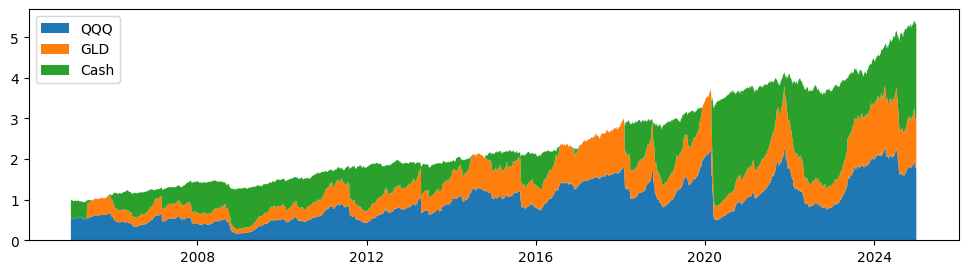

In [24]:
plt.figure(figsize=(12,3))
holdings = pd.DataFrame(sim.pw * sim.pv, index=dl.timeline, columns=dl.tickers+["Cash"])
plt.stackplot(holdings.index, holdings.T, labels=holdings.columns)
plt.legend()
plt.show()

In [25]:
dl._asset_mask

array([[ True, False],
       [ True, False],
       [ True, False],
       ...,
       [ True,  True],
       [ True,  True],
       [ True,  True]], shape=(5033, 2))

In [26]:
# from time import time
# start = time()
# for i in range(100):
#     run_backtest(
#         strategy=fw,
#         spread=SPREAD
#     )
# print(time() - start)

In [27]:
# tickers = ["LQD", "SMH", "XLK", "AGG"] # , "QQQ", "GLD", "AGG", "XLK"
# # tickers = ["QQQ", "AGG", "XLK"]
# for t in tickers:
#     assert t in assets_remaining

# op = mod.OptimizerParams(
#     w_prev=np.zeros(len(tickers)),
#     w_max=0.7,
#     gamma=2e-4,
#     L=0.0,
#     vc_lim=((1.08)**(1/252))-1.0,
# )

# # data_bt["alpha"] = np.ones_like(data_bt["alpha"])

# lookahead = 0  # months
# holdings: pd.DataFrame = mod.run_backtest(
#     tickers=tickers,
#     universe=rd.columns,
#     data_bt=data_bt,
#     lookahead=lookahead,
#     op=op,
#     fixed_weights=False,
# )

# # r_tot = (performance+1).prod() - 1 
# # w_avg = weights.round(3).mean(axis=0).round(3)
# # vol_ann = performance.std() * 12**0.5 * 100 # realized

# # print(f"Sharpe ratio: {sharpe:8.3f}")
# # print(f"Period return: {r_tot:7.3f}")
# # print(f"Avg weights: {w_avg}")
# # print(f"Realized vol: {vol_ann:7.3}%")
# # print(f"Period: {START_DATE} : {END_DATE}")

# nav = holdings.sum(axis=1)
# w_port = holdings.div(nav, axis=0)

# rp = nav.pct_change().dropna()
# rf = ffr["DFF"].reindex(rp.index)
# mod.sharpe_ratio(rp, rf).round(3).item()

NameError: name 'rp' is not defined

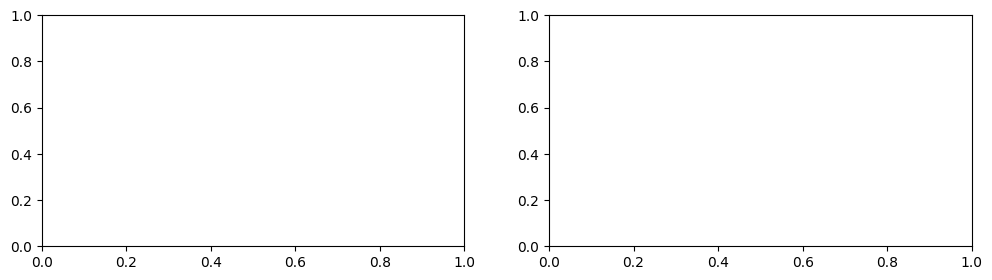

In [28]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,3))
ax1: plt.Axes
ax2: plt.Axes
ax1.plot((rp+1).cumprod()-1)
ax1.set_title("Portfolio Performance (Cumprod Returns)")

w_port = w_port.resample("QE").mean()
_ = ax2.stackplot(w_port.index, w_port.T, labels=w_port.columns)
ax2.set_title("Portfolio Weights (Stackplot")
ax2.legend()
plt.show()

In [ ]:
# |------------.------.---.--.-|-|
#                              t 
# The first 2 years (minus a day) are lost due to lookback (trailing returns)
# The last 1 month is lost due to trying to predict the future month - no lookahead!

# # plotting thetas over time
# features_all = ["Const"] + features_ret + features_mac
# pd.DataFrame(theta.mean(axis=1), columns=features_all, index=df_ref.index).plot()
# plt.show()

# # plotting pca graph
# Am = data[assets_remaining[0]]
# Um, d, VmT = np.linalg.svd(Am)
# Um.shape, d.shape, VmT.shape
# d /= d.sum()

# plt.figure(figsize=(7,2))
# plt.plot(d.cumsum())
# plt.axhline(y=0.90, c="r")
# plt.title(f"PCA - {assets_remaining[0]}")
# # plt.axvline(x=8, c="k", ls=":")
# plt.show()

In [ ]:
# NOTE Simple way of getting an alpha

# rd = rd.loc[START_DATE:END_DATE]
# rd = rd.loc[:, ~rd.isna().any(axis=0)]

# corr = rd.rolling(252).corr().dropna()
# corr_avg = corr.groupby(level=0).apply(lambda x: (x - np.eye(rd.shape[1])).mean(axis=0).abs())
# corr_avg

# ffr = ffr.reindex(rd.index)
# excess = rd.sub(ffr.values, axis=0)
# mu = excess.rolling(252).mean().dropna()
# sd = rd.rolling(252).std().dropna()
# shrp_sld = mu / sd * np.sqrt(252)

# beta = 1.0
# gamma = 1.0
# alphas = beta * shrp_sld - gamma * corr_avg
# rd = rd.reindex(alphas.index)

In [ ]:
# alphas = df_prd.rank(axis=1)
# rd = rd.loc[alphas.index, assets_remaining]

# assert rd.isna().any().any() == False

# ffr = (ffr + 1)**(1/252) - 1  # transform to daily
# ffr = ffr.reindex(rd.index)
# assert ffr.isna().any().any() == False

# lookback = 42 # days
# data_bt = backtest_data(
#     alphas=alphas,
#     rd=rd,
#     ffr=ffr,
#     lookback=lookback, 
#     rebal_freq="M"
#     )
# data_bt.keys()